In [8]:
import numpy as np
import functions as func
import radar_functions as rf
import math
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
def build_theor_radar_image(params: tuple, phi, position_vecs, mult=400, lt_num=30,  pow_coeff: float = 2):
    """
    calculates the theoretical radar images, compares them with obsertational data, returns the list of
    red/green overlay of observational and theoretical data, and a pixelwise difference between images
    """
    ps = rf.Parameters(a1=params[0] * mult, b1=params[1] * mult, c1=params[2] * mult,
                    a2=params[3] * mult, b2=params[4] * mult, c2=params[5] * mult,
                    l=params[6], b=params[7], init_phase=params[8], rot_per=params[9], radar_sat=params[10])
    # number of points in latitude and longitude used in ray tracing
    cosl = math.cos(ps.ecl_longitude)
    sinl = math.sin(ps.ecl_longitude)
    cosb = math.cos(ps.ecl_latitude)
    sinb = math.sin(ps.ecl_latitude)

    body = rf.create_body(parameters=ps, n_points=int(lt_num / 2))
    # subplot(r,c) provide the no. of rows and columns
    sinphi = math.sin(phi)
    cosphi = math.cos(phi)
    ex0 = position_vecs['x']
    ey0 = position_vecs['y']
    ez0 = position_vecs['z']
    e_vecs = np.array(rf.rotate(ex0, ey0, ez0,
                             sinl, cosl, sinb, cosb,
                             sinphi, cosphi))

    theor_radar_img = rf.theor_radar_image_vec(body=body,
                                            e_vecs=e_vecs,
                                            P=ps.rot_per,
                                            N_radar_pixels=90,
                                            dr=18.75,
                                            dnu=0.96,
                                            pow_coeff=pow_coeff)
    theor_radar_img = rf.saturate_img(theor_radar_img, ps) - 0.1


    return theor_radar_img

In [2]:
# create two ellipsoids with specified parameters
distance = 3
ellips1 = func.Ellipsoid(a=2, b=1, c=1)
ellips2 = func.Ellipsoid(a=1, b=1, c=1)
# create body from two ellipsis
body = func.Body(ellips1, ellips2, distance=3,
                 eq_latitude=0,
                 eq_longitude=np.pi / 2,
                 init_phase=0., rotation_period=5.0/24)
print(ellips1)
print(ellips2)
print(body)

Ellipsis with axes: a=2, b=1, c=1
Ellipsis with axes: a=1, b=1, c=1
Body consists of:
Ellipsis with axes: a=2, b=1, c=1,
Ellipsis with axes: a=1, b=1, c=1,
lat=0.0 deg, lon=90.0 deg, phase=0.0, distance=3


In [3]:
print(ellips1.normals.shape)

(3, 20, 40)


In [4]:
# flatten the coordinates of the first ellipsoid
distance = 3
xs1 = np.ravel(ellips1.surface[0])
ys1 = np.ravel(ellips1.surface[1])
zs1 = np.ravel(ellips1.surface[2])
norms_x1 = np.ravel(ellips1.normals[0])
norms_y1 = np.ravel(ellips1.normals[1])
norms_z1 = np.ravel(ellips1.normals[2])

# flatten the coordinates of the second
xs2 = np.ravel(ellips2.surface[0] + distance)
ys2 = np.ravel(ellips2.surface[1])
zs2 = np.ravel(ellips2.surface[2])
norms_x2 = np.ravel(ellips2.normals[0])
norms_y2 = np.ravel(ellips2.normals[1])
norms_z2 = np.ravel(ellips2.normals[2])

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import numpy as np
mark_size = 5

# Create the figure
fig = go.Figure()

scat1 = go.Scatter3d(x=xs1,
                   y=ys1,
                   z=zs1, name='ellipsoid1',
                     marker=dict(
                        size=mark_size,
                        color='red',                # set color to an array/list of desired values
                        opacity=1))

scat2 = go.Scatter3d(x=xs2,
                   y=ys2,
                   z=zs2, name='ellipsoid2',
                      marker=dict(
                        size=mark_size,
                        color='blue',                # set color to an array/list of desired values
                        opacity=1)
                     )
# build normals
norms1 = go.Scatter3d(x=norms_x1 + xs1,
                   y=norms_y1 + ys1,
                   z=norms_z1+zs1, name='normals1',
                    mode='lines')

# Define the starting points of the vectors (x, y, z)
start_points = np.array([xs1+norms_x1, ys1+norms_y1, zs1+norms_z1]).T

# Define the vectors to plot (u, v, w)
vectors = np.array([norms_x1+xs1, norms_y1+ys1, norms_z1+zs1]).T

# Add the vector arrows using the Cone class
for start, vector in zip(start_points, vectors):
    fig.add_trace(go.Cone(
        x=[start[0]],
        y=[start[1]],
        z=[start[2]],
        u=[vector[0]],
        v=[vector[1]],
        w=[vector[2]],
        sizemode='absolute',
        colorscale=[[0, 'white'], [1, 'white']],
        sizeref=0.1,
        showscale=False
    ))
#fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_traces(scat1)
fig.add_traces(scat2)
#fig.add_traces(norms1)
fig.show()

In [7]:
# generate requested epochs for the query
start_epoch = 2459180.5
epochs = start_epoch + np.arange(5, 5.4, 0.002)
reduc_epoch = epochs - start_epoch
#print(epochs)
print(len(epochs))

201


In [48]:
# same position for earth and sun
# same position for earth and sun
state_vecs_sun = np.zeros([201, 3])
state_vecs_sun[:, 1] = 1
state_vecs_sun = pd.DataFrame(state_vecs_sun, columns=['x', 'y', 'z'])
state_vecs_sun['reduc_epoch'] = reduc_epoch

#tate_vecs_earth = np.copy(state_vecs_sun)
state_vecs_earth = np.zeros([201, 4])
state_vecs_earth[:, 2] = 1
state_vecs_earth[:, 3] = reduc_epoch
state_vecs_earth = pd.DataFrame(state_vecs_earth, columns=['x', 'y', 'z', 'reduc_epoch'])


In [47]:
state_vecs_earth.iloc[0]

x              1.0
y              0.0
z              0.0
reduc_epoch    5.0
Name: 0, dtype: float64

In [61]:
params=[2, 1, 1, 1, 1, 1, 0, np.pi / 2, 0, 5.0/24, 2000]
theor_img = build_theor_radar_image(params=params, phi=0, position_vecs=state_vecs_earth.iloc[0])


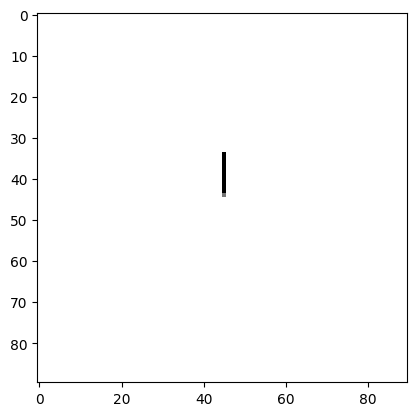

In [62]:
plt.imshow(theor_img, interpolation='nearest', cmap='gray_r')
plt.show()

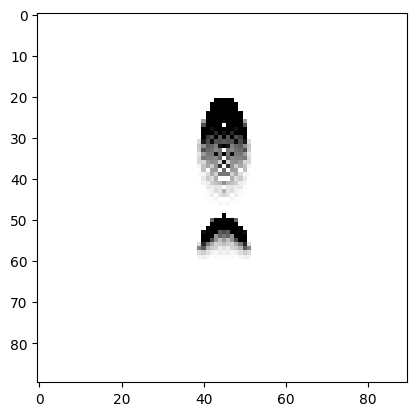

In [72]:
# very small component
params=[2, 1, 1, 1, 1, 1, 0, np.pi/4, 0, 5.0/24, 2000]
theor_img = build_theor_radar_image(params=params, phi=0, position_vecs=state_vecs_earth.iloc[0])
plt.imshow(theor_img, interpolation='nearest', cmap='gray_r')
plt.show()


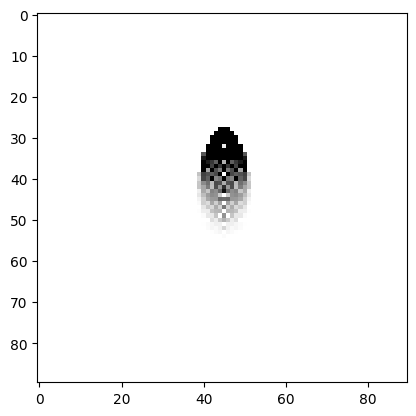

In [75]:
# very small component
params=[2, 1, 1, 1e-3, 1e-3, 1e-3, 0, np.pi/4, 0, 5.0/24, 2000]
theor_img = build_theor_radar_image(params=params, phi=0, position_vecs=state_vecs_earth.iloc[0])
plt.imshow(theor_img, interpolation='nearest', cmap='gray_r')
plt.show()